In [1]:
from pytential.sympy_pytential import sympy_pytential
from pytential.reduce import min_pytential
import numpy as np
from sympy import log, symbols
import matplotlib.pyplot as plt

This file demonstrates how to create, combine, and manipulate pytentials.  Equibilriation is used to reduce free variables. 

# Create phases

Create two binary ideal solutions

In [2]:
c0a, c1a, c0b, c1b, Va, Vb = symbols('c0a, c1a, c0b, c1b, Va, Vb')

In [3]:
RT = 8.134*300
kappa = 10000
fa_sp = c0a*RT*(1+log(c0a/(c0a+c1a))) +c1a*RT*(0+log(c1a/(c0a+c1a)))+(c0a+c1a)*kappa/2*(log(Va/(c0a+c1a)))**2
fb_sp = c0b*RT*(0+log(c0b/(c0b+c1b))) +c1b*RT*(1+log(c1b/(c0b+c1b)))+(c0b+c1b)*kappa/2*(log(Vb/(c0b+c1b)))**2

In [4]:
fa = sympy_pytential(fa_sp)
fb = sympy_pytential(fb_sp)

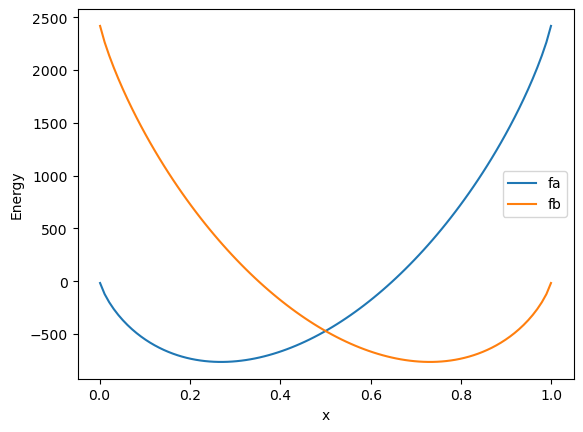

In [5]:
x_values = np.linspace(0.001, .999, 100)
ya = fa(c0a=x_values, c1a=1-x_values, Va = 1)
yb = fb(c0b=x_values, c1b=1-x_values, Vb = 1)

plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.xlabel('x')
plt.ylabel('Energy')
plt.legend()
plt.show()

In [6]:
import plotly.graph_objects as go
X, Y = np.meshgrid(x_values, x_values)
Z = fa(Va=1, c0a = X, c1a = Y)

fig = go.Figure()

# Add the 3D surface plot for fa
fig.add_trace(go.Surface(
    z=Z,
    x=x_values, 
    y=x_values, 
    colorscale='Viridis',
    name='fa surface',
    showlegend=True
))

# Add the line where c0a + c1a = Va
fig.add_trace(go.Scatter3d(
    x=x_values, 
    y=1-x_values, 
    z=fa(c0a=x_values, c1a=1-x_values, Va=1), 
    mode='lines', 
    name='c0a + c1a = Va', 
    line=dict(color='red', width=4),
    showlegend=True
))

# Update layout for the plot
fig.update_layout(
    title='3D Surface Plot of fa(x_values, x_values, Va=1)',
    legend=dict(title="Legend", x=0.8, y=0.9, bgcolor="rgba(255, 255, 255, 0.7)"),
    scene=dict(
        xaxis_title='c0a',
        yaxis_title='c1a',
        zaxis_title='fa values',
        aspectratio=dict(x=1, y=1, z=1)
    )
)
fig.show()

# Combine functions

Combine functions into a composite pytential

In [7]:
f = fa+fb
c0, c1 = symbols('c0, c1')
f_constrained = f.add_constraints_sym([c0a+c0b-c0, c1a+c1b-c1, Va+Vb-1]) 
print(f)

x = ['Va', 'Vb', 'c0a', 'c0b', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1) + (5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))**2 + (5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))**2

f'(x)= [2*(5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))/Va, 2*(5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))/Vb, -2440.2*c1a/(c0a + c1a) + 2440.2*(c0a + c1a)*(-c0a/(c0a + c1a)**2 + 1/(c0a + c1a)) + 5000*log(Va/(c0a + c1a))**2 + 2440.2*log(c0a/(c0a + c1a)) + 2440.2 - 2*(5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))/(c0a + c1a), -2440.2*c1b/(c0b + c1b) + 2440.2*(c0b + c1b)*(-c0b/(c0b + c1b)**2 + 1/(c0b + c1b)) + 5000*log(Vb/(c0b + c1b))**2 + 2440.2*log(c0b/(c0b + c1b)) - 2*(5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))/(c0b + c1b), -2440.2*c0a/(c0a + c1a) + 2440.2*(c0a + c1a)*(-c1a/(c0a + c1a)**2 + 1/(c0a + c1a)) + 5000*log(Va/(c0a + c1a))**2 + 2440.2*log(c1a/(c0a + c1a)) - 2*(5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))/

Add a constraint for the total x. Note the function is now an argument of x1, x2, and x

In [8]:
f_min = min_pytential(f_constrained, ['c0', 'c1'])
x_values2 = np.linspace(0.0001, .9999, 50)
#print(f_min(c0=.5, c1=.5))
ym = f_min(c0=x_values2, c1=1-x_values2)

/usr/lib/python3/dist-packages/scipy/optimize/_optimize.py:404: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds



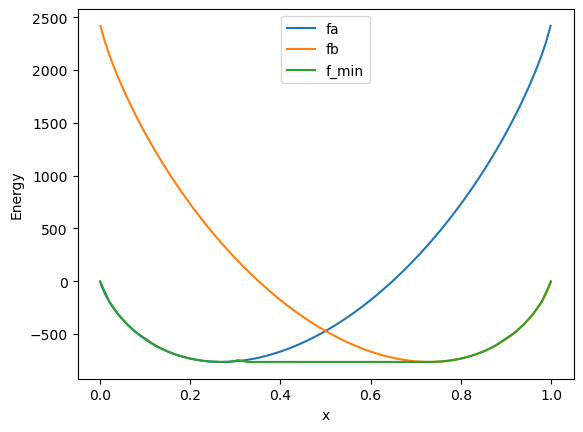

In [9]:
plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.plot(x_values2, ym, label='f_min')
plt.xlabel('x')
plt.ylabel('Energy')
plt.legend()
plt.show()

In [10]:
f_constrained2 = f_constrained.add_constraints_sym([c0+c1-1])
print(f_constrained2)

x = ['Va', 'Vb', 'c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1) + (5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))**2 + (5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))**2

f'(x)= [2*(5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))/Va, 2*(5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))/Vb, 0, -2440.2*c1a/(c0a + c1a) + 2440.2*(c0a + c1a)*(-c0a/(c0a + c1a)**2 + 1/(c0a + c1a)) + 5000*log(Va/(c0a + c1a))**2 + 2440.2*log(c0a/(c0a + c1a)) + 2440.2 - 2*(5000*c0a + 5000*c1a)*log(Va/(c0a + c1a))/(c0a + c1a), -2440.2*c1b/(c0b + c1b) + 2440.2*(c0b + c1b)*(-c0b/(c0b + c1b)**2 + 1/(c0b + c1b)) + 5000*log(Vb/(c0b + c1b))**2 + 2440.2*log(c0b/(c0b + c1b)) - 2*(5000*c0b + 5000*c1b)*log(Vb/(c0b + c1b))/(c0b + c1b), 0, -2440.2*c0a/(c0a + c1a) + 2440.2*(c0a + c1a)*(-c1a/(c0a + c1a)**2 + 1/(c0a + c1a)) + 5000*log(Va/(c0a + c1a))**2 + 2440.2*log(c1a/(c0a + c1a)) - 2*(5000*c0a + 5000*c1a)*lo

In [11]:
f_min2 = min_pytential(f_constrained2, ['c0', 'Va'])

In [12]:
import numpy as np
import plotly.graph_objects as go

# Define the range of values for the two arguments
c0_values = np.linspace(0.001, 0.999, 10)  # Range for c0
Va_values = np.linspace(0.001, 0.999, 10)  # Range for Va

# Create a meshgrid for the two arguments
C0, Va = np.meshgrid(c0_values, Va_values)

# Evaluate f_min2 for each pair of (c0, Va)
F_min2 = np.zeros_like(C0)
for i in range(C0.shape[0]):
    for j in range(C0.shape[1]):
        F_min2[i, j] = f_min2(c0=C0[i, j], Va=Va[i, j])

In [13]:
zlim = [-800, 2500]
# Create a Plotly surface plot
fig = go.Figure(data=[
    go.Surface(
        z=F_min2,
        x=C0,
        y=Va,
        colorscale='Viridis',
        cmin=zlim[0],  # Set the minimum value for the color scale
        cmax=zlim[1]   # Set the maximum value for the color scale
    )
])

# Add a line plot for f_a at Va = 1
fa_values_Va_1 = fa(c0a=c0_values, c1a=1-c0_values, Va=1)
fig.add_trace(go.Scatter3d(
    x=c0_values,
    y=[1] * len(c0_values),  # Va = 1
    z=fa_values_Va_1,
    mode='lines',
    name='f_a at Va=1',
    line=dict(color='blue', width=4)
))

# Add a line plot for f_b at Va = 0
fb_values_Va_0 = fb(c0b=c0_values, c1b=1-c0_values, Vb=1)
fig.add_trace(go.Scatter3d(
    x=c0_values,
    y=[0] * len(c0_values),  # Va = 0
    z=fb_values_Va_0,
    mode='lines',
    name='f_b at Va=0',
    line=dict(color='green', width=4)
))

# Add labels and title
fig.update_layout(
    title="Surface Plot of f_min2",
    scene=dict(
        xaxis_title="c0",
        yaxis_title="Va",
        zaxis_title="f_min2",
        zaxis=dict(range=zlim),  # Fix the z-axis range
    ),
)

# Show the plot
fig.show()

In [14]:
x0 = f_min2.min_fcn([0.5, .5])[1]
print(x0)

{'c0': 0.5, 'Va': 0.5, 'Vb': 0.5, 'c0a': 0.13447116976882362, 'c0b': 0.3655288302311764, 'c1': 0.5, 'c1a': 0.36552915796231034, 'c1b': 0.13447084203768966}


In [18]:
fq = f_constrained2.quadratic_expansion(x0)
print(fq)

x = ['Va', 'Vb', 'c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 0.5*Va*(20000.026218495*Va - 20000.0131092411*c0a - 20000.0131092411*c1a) - 0.00655462482807253*Va + 0.5*Vb*(19999.9737815136*Vb - 19999.9868907503*c0b - 19999.9868907503*c1b) + 0.00655462053005475*Vb + 0.5*c0a*(-20000.0131092411*Va + 33266.2438817813*c0a + 15119.6031989117*c1a) - 764.407883874334*c0a + 0.5*c0b*(-19999.9868907503*Vb + 21795.4040101997*c0b + 15119.5968010756*c1b) - 764.429189798286*c0b + 0.5*c1a*(-20000.0131092411*Va + 15119.6031989117*c0a + 21795.4044225492*c1a) - 764.417091602094*c1a + 0.5*c1b*(-19999.9868907503*Vb + 15119.5968010756*c0b + 33266.2817107756*c1b) - 764.423741428016*c1b - 764.421169877513

f'(x)= [20000.026218495*Va - 20000.0131092411*c0a - 20000.0131092411*c1a - 0.00655462482807253, 19999.9737815136*Vb - 19999.9868907503*c0b - 19999.9868907503*c1b + 0.00655462053005475, 0, -20000.0131092411*Va + 33266.2438817813*c0a + 15119.6031989117*c1a - 764.407883874334, -19999.9868907503*Vb + 21795.40